# Research Pulse — arXiv Data Pipeline

Run through this notebook, which starts from data loading, processing to finally saving the cleaned, scoped dataset. This will be used in the Power BI to create the dashbaords.

In [1]:
import json, csv, os, re, collections
from email.utils import parsedate_to_datetime

RAW_PATH = YOUR_INPUT_DIR
OUT_DIR  = YOUR_OUTPUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)

size_gb = os.path.getsize(RAW_PATH) / 1024**3
print(f"Raw file: {RAW_PATH}")
print(f"Size: {size_gb:.2f} GB")

Raw file: C:\Users\thill\jupyter_folder\portolfio_projects\powerbi\arxiv-metadata-oai-snapshot.json
Size: 5.15 GB


## Step 1 · What's actually in one record?

Before touching the full file, looking at a single line. This is a JSON-lines file, one paper per line.


In [5]:
with open(RAW_PATH, encoding="utf-8") as f:
    first_line = f.readline()
first_line

'{"id":"0704.0001","submitter":"Pavel Nadolsky","authors":"C. Bal\\\\\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan","title":"Calculation of prompt diphoton production cross sections at Tevatron and\\n  LHC energies","comments":"37 pages, 15 figures; published version","journal-ref":"Phys.Rev.D76:013009,2007","doi":"10.1103/PhysRevD.76.013009","report-no":"ANL-HEP-PR-07-12","categories":"hep-ph","license":null,"abstract":"  A fully differential calculation in perturbative quantum chromodynamics is\\npresented for the production of massive photon pairs at hadron colliders. All\\nnext-to-leading order perturbative contributions from quark-antiquark,\\ngluon-(anti)quark, and gluon-gluon subprocesses are included, as well as\\nall-orders resummation of initial-state gluon radiation valid at\\nnext-to-next-to-leading logarithmic accuracy. The region of phase space is\\nspecified in which the calculation is most reliable. Good agreement is\\ndemonstrated with data from the Fermilab Tevatron

In [7]:
record = json.loads(first_line)
for k, v in record.items():
    preview = str(v)
    if len(preview) > 120:
        preview = preview[:120] + "..."
    print(f"{k:15s} {preview}")

id              0704.0001
submitter       Pavel Nadolsky
authors         C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan
title           Calculation of prompt diphoton production cross sections at Tevatron and
  LHC energies
comments        37 pages, 15 figures; published version
journal-ref     Phys.Rev.D76:013009,2007
doi             10.1103/PhysRevD.76.013009
report-no       ANL-HEP-PR-07-12
categories      hep-ph
license         None
abstract          A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive pho...
versions        [{'version': 'v1', 'created': 'Mon, 2 Apr 2007 19:18:42 GMT'}, {'version': 'v2', 'created': 'Tue, 24 Jul 2007 20:10:27 G...
update_date     2008-11-26
authors_parsed  [['Balázs', 'C.', ''], ['Berger', 'E. L.', ''], ['Nadolsky', 'P. M.', ''], ['Yuan', 'C. -P.', '']]


14 fields per paper. The ones that matter for modeling:
- `categories`: space-separated, often more than one per paper → needs a bridge table
- `authors_parsed`: list of `[last, first, suffix]` → needs a bridge table
- `versions`: full revision history; `versions[0]['created']` is the *true* first-submision date (more accurate than `update_date`: which just reflects the last metadata touch)
- `abstract`: free text, used only to *derive* subfield tags (LLM/RAG/Difusion/...) since arXiv has no category for those


## Step 2 · Scanning the whole file

Scanning the whole record to get- total count, date range, and how many papers touch each top-level archive


In [8]:
total = 0
prefix_counter = collections.Counter()
cat_counter = collections.Counter()
min_date, max_date = None, None

with open(RAW_PATH, encoding="utf-8") as f:
    for line in f:
        total += 1
        rec = json.loads(line)
        cats = rec.get("categories", "").split()
        for c in cats:
            cat_counter[c] += 1
            prefix_counter[c.split(".")[0]] += 1
        d = rec.get("update_date")
        if d:
            if min_date is None or d < min_date: min_date = d
            if max_date is None or d > max_date: max_date = d

print(f"TOTAL RECORDS: {total:,}")
print(f"DATE RANGE (update_date): {min_date} to {max_date}")
print()
print("Top-level archive counts:")
for k, v in prefix_counter.most_common(10):
    print(f"  {k:10s} {v:>10,}")

TOTAL RECORDS: 3,164,528
DATE RANGE (update_date): 2007-05-23 to 2026-09-11

Top-level archive counts:
  cs          1,531,039
  math        1,065,670
  cond-mat      560,400
  astro-ph      479,173
  physics       380,883
  hep-ph        199,160
  quant-ph      186,222
  hep-th        185,509
  stat          183,126
  eess          144,110


## Step 3 Full category listing

In [ ]:
groups = collections.defaultdict(list)
for cat, cnt in cat_counter.items():
    groups[cat.split(".")[0]].append((cat, cnt))

print(f"Distinct category codes: {len(cat_counter)}")
print(f"Distinct archives: {len(groups)}")
print()
for prefix in sorted(groups, key=lambda p: -sum(c for _, c in groups[p]))[:8]:
    total_p = sum(c for _, c in groups[prefix])
    top3 = sorted(groups[prefix], key=lambda x: -x[1])[:3]
    print(f"{prefix:10s} {total_p:>9,} papers, {len(groups[prefix]):2d} codes  |  top: "
          + ", ".join(f"{c}({n:,})" for c, n in top3))


## Step 4 Scoping for the dashboard

The dashboard doesn't need all 1.53M `cs.*` related papers, as most of that is systems, theory, databases, etc. We only  need the papers relating to the AI field. Two options were considered:

- **Core 4 only**: `cs.AI`, `cs.LG`, `cs.CL`, `cs.CV` — cleanest story, smallest data
- **Core 4 + 3 adjacent** *(chosen)*: adds `stat.ML` (heavily associated with `cs.LG`), `cs.RO` (robotics AI), `cs.NE` (neural methods).

In [ ]:
TARGET_CATS = {"cs.AI", "cs.LG", "cs.CL", "cs.CV", "stat.ML", "cs.RO", "cs.NE"}

hits = 0
year_counter = collections.Counter()
with open(RAW_PATH, encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        cats = set(rec.get("categories", "").split())
        if cats & TARGET_CATS:
            hits += 1
            d = rec.get("update_date", "")
            if len(d) >= 4:
                year_counter[d[:4]] += 1

print(f"Union of 7 categories: {hits:,} papers ({hits/total*100:.1f}% of the full dataset)")
print()
print("By year:")
for y in sorted(year_counter):
    print(f"  {y}: {year_counter[y]:>8,}")


That's the whole reason this project exists: **~2K papers/year before 2012 and to 130K in partial-2026 alone.** Full history (2007–2026) is kept rather than trimming to "last 5 years", as the acceleration curve *is* the story, and 644K records is small regardless of date range.

## Step 5  Building the star schema

Five output tables:

| Table | Grain | Purpose |
|---|---|---|
| `Fact_Papers` | 1 row / paper | title, primary category, author/category counts, true submission date |
| `Bridge_Paper_Category` | 1 row / paper-category pair | powers the many-to-many category dimension |
| `Bridge_Paper_Author` | 1 row / paper-author pair | powers the many-to-many author dimension |
| `Bridge_Paper_Subfield` | 1 row / paper-tag match | derived LLM/RAG/Agents/... tags |
| `Dim_Category`, `Dim_SubfieldTag` | lookup tables | names + which categories are "core target" vs. co-tagged |


In [ ]:
CATEGORY_NAMES = {
    "cs.AI": "Artificial Intelligence", "cs.LG": "Machine Learning",
    "cs.CL": "Computation & Language", "cs.CV": "Computer Vision",
    "stat.ML": "Statistics - Machine Learning", "cs.RO": "Robotics",
    "cs.NE": "Neural & Evolutionary Computing",
}

SUBFIELD_RULES = [
    ("LLM", re.compile(r"\b(large language model|llms?\b|gpt-?\d|chatgpt|instruction[- ]tuning|foundation model)\b", re.I)),
    ("Diffusion", re.compile(r"\b(diffusion model|denoising diffusion|score-based generative|ddpm)\b", re.I)),
    ("RAG", re.compile(r"\b(retrieval-augmented|retrieval augmented generation|\brag\b)\b", re.I)),
    ("Agents", re.compile(r"\b(autonomous agents?|multi-agent|llm agents?|tool[- ]use|agentic)\b", re.I)),
    ("Reinforcement Learning", re.compile(r"\b(reinforcement learning|policy gradient|q-learning|actor-critic|markov decision process)\b", re.I)),
    ("Multimodal", re.compile(r"\b(vision-language|multimodal|multi-modal|vision language model|\bvlm\b)\b", re.I)),
    ("Generative Models", re.compile(r"\b(generative adversarial|\bgan\b|generative model|variational autoencoder|\bvae\b)\b", re.I)),
    ("Graph Learning", re.compile(r"\b(graph neural network|\bgnn\b|graph representation learning)\b", re.I)),
    ("Robotics", re.compile(r"\b(robot(ic)?s?\b|manipulation|motion planning|grasping)\b", re.I)),
    ("Explainability", re.compile(r"\b(explainab\w*|interpretab\w*|attention visualization)\b", re.I)),
]

def first_submitted_date(versions):
    try:
        return parsedate_to_datetime(versions[0]["created"]).strftime("%Y-%m-%d")
    except Exception:
        return ""

def tag_subfields(title, abstract):
    text = f"{title} {abstract}"
    return [tag for tag, pattern in SUBFIELD_RULES if pattern.search(text)]


### A real bug: the first version of the Explainability rule

The initial code only matched **39 papers out of 644K**. Using the `\b` on both sides forces an exact whole word match, and `"explainab"` is never a complete word on its own, it's always `"explainable"` or `"explainability"`. so had to use \w* as well.


In [ ]:
buggy = re.compile(r"\b(explainab|interpretab)\b", re.I)
fixed = re.compile(r"\b(explainab\w*|interpretab\w*)\b", re.I)

test = "We propose an interpretable, explainable model for medical diagnosis."
print("Buggy pattern matches:", bool(buggy.search(test)))
print("Fixed pattern matches:", bool(fixed.search(test)))


## Step 6 Runing the full extraction

One run over all 3.16M records: filter to the 7 target categories, write `Fact_Papers` + the three bridge tables, tag subfields.


In [ ]:
fact_path = os.path.join(OUT_DIR, "Fact_Papers.csv")
bridge_cat_path = os.path.join(OUT_DIR, "Bridge_Paper_Category.csv")
bridge_author_path = os.path.join(OUT_DIR, "Bridge_Paper_Author.csv")
bridge_tag_path = os.path.join(OUT_DIR, "Bridge_Paper_Subfield.csv")

n_read = n_kept = 0
seen_cats = set()

with open(fact_path, "w", newline="", encoding="utf-8") as fact_f, \
     open(bridge_cat_path, "w", newline="", encoding="utf-8") as bcat_f, \
     open(bridge_author_path, "w", newline="", encoding="utf-8") as bauth_f, \
     open(bridge_tag_path, "w", newline="", encoding="utf-8") as btag_f:

    fact_w = csv.writer(fact_f); bcat_w = csv.writer(bcat_f)
    bauth_w = csv.writer(bauth_f); btag_w = csv.writer(btag_f)

    fact_w.writerow(["PaperID", "Title", "PrimaryCategory", "NumCategories",
                      "NumAuthors", "SubmittedDate", "UpdateDate"])
    bcat_w.writerow(["PaperID", "CategoryCode"])
    bauth_w.writerow(["PaperID", "AuthorName"])
    btag_w.writerow(["PaperID", "SubfieldTag"])

    with open(RAW_PATH, encoding="utf-8") as f:
        for line in f:
            n_read += 1
            rec = json.loads(line)
            cats = rec.get("categories", "").split()
            if not (set(cats) & TARGET_CATS):
                continue
            n_kept += 1

            paper_id = rec["id"]
            title = " ".join(rec.get("title", "").split())
            abstract = " ".join(rec.get("abstract", "").split())
            authors_parsed = rec.get("authors_parsed", [])

            fact_w.writerow([paper_id, title, cats[0] if cats else "", len(cats),
                              len(authors_parsed), first_submitted_date(rec.get("versions", [])),
                              rec.get("update_date", "")])

            for c in cats:
                seen_cats.add(c)
                bcat_w.writerow([paper_id, c])

            for a in authors_parsed:
                last, first = (a[0] if len(a) > 0 else ""), (a[1] if len(a) > 1 else "")
                name = f"{first} {last}".strip()
                if name:
                    bauth_w.writerow([paper_id, name])

            for tag in tag_subfields(title, abstract):
                btag_w.writerow([paper_id, tag])

            if n_kept % 100_000 == 0:
                print(f"  ...{n_kept:,} matched so far ({n_read:,} scanned)")

with open(os.path.join(OUT_DIR, "Dim_Category.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["CategoryCode", "CategoryName", "Archive", "IsCoreTarget"])
    for c in sorted(seen_cats):
        w.writerow([c, CATEGORY_NAMES.get(c, c), c.split(".")[0], c in TARGET_CATS])

with open(os.path.join(OUT_DIR, "Dim_SubfieldTag.csv"), "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["SubfieldTag"])
    for tag, _ in SUBFIELD_RULES:
        w.writerow([tag])

print()
print(f"Scanned {n_read:,} records, kept {n_kept:,} ({n_kept/n_read*100:.1f}%)")
print(f"Distinct categories touched by kept papers: {len(seen_cats)}")


## Step 7 · Verifying the output

In [12]:
import pandas as pd

for fn in ["Fact_Papers.csv", "Bridge_Paper_Category.csv", "Bridge_Paper_Author.csv", "Bridge_Paper_Subfield.csv"]:
    path = os.path.join(OUT_DIR, fn)
    size_mb = os.path.getsize(path) / 1024**2
    print(f"{fn:30s} {size_mb:8.2f} MB")

papers = pd.read_csv(os.path.join(OUT_DIR, "Fact_Papers.csv"))
tags = pd.read_csv(os.path.join(OUT_DIR, "Bridge_Paper_Subfield.csv"))
print()
print(f"Fact_Papers: {len(papers):,} rows")
papers.head()


Fact_Papers.csv                   76.16 MB
Bridge_Paper_Category.csv         23.64 MB
Bridge_Paper_Author.csv           73.82 MB
Bridge_Paper_Subfield.csv          7.02 MB


C:\Users\thill\AppData\Local\Temp\ipykernel_42152\581289346.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  papers = pd.read_csv(os.path.join(OUT_DIR, "Fact_Papers.csv"))



Fact_Papers: 643,816 rows


C:\Users\thill\AppData\Local\Temp\ipykernel_42152\581289346.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tags = pd.read_csv(os.path.join(OUT_DIR, "Bridge_Paper_Subfield.csv"))


,PaperID,Title,PrimaryCategory,NumCategories,NumAuthors,SubmittedDate,UpdateDate
0,704.0047,Intelligent location of simultaneously active ...,cs.NE,2,2,2007-04-01,2009-09-29
1,704.005,Intelligent location of simultaneously active ...,cs.NE,2,2,2007-04-01,2007-05-23
2,704.0304,The World as Evolving Information,cs.IT,4,1,2007-04-03,2013-04-05
3,704.0671,Learning from compressed observations,cs.IT,3,1,2007-04-05,2016-11-15
4,704.0954,Sensor Networks with Random Links: Topology De...,cs.IT,3,2,2007-04-06,2009-11-13


In [10]:
tag_dist = tags["SubfieldTag"].value_counts()
tag_dist_pct = (tag_dist / len(papers) * 100).round(1)
pd.DataFrame({"papers": tag_dist, "% of all papers": tag_dist_pct})


,papers,% of all papers
SubfieldTag,,
LLM,82221,12.8
Robotics,50829,7.9
Multimodal,46421,7.2
Reinforcement Learning,40691,6.3
Explainability,36025,5.6
Agents,21728,3.4
Generative Models,19423,3.0
Diffusion,8691,1.3
Graph Learning,8034,1.2


## Step 8 · The growth curve

This is the actual result i have been looking for. Papers per year for the 7 target categories, straight from `SubmittedDate`.


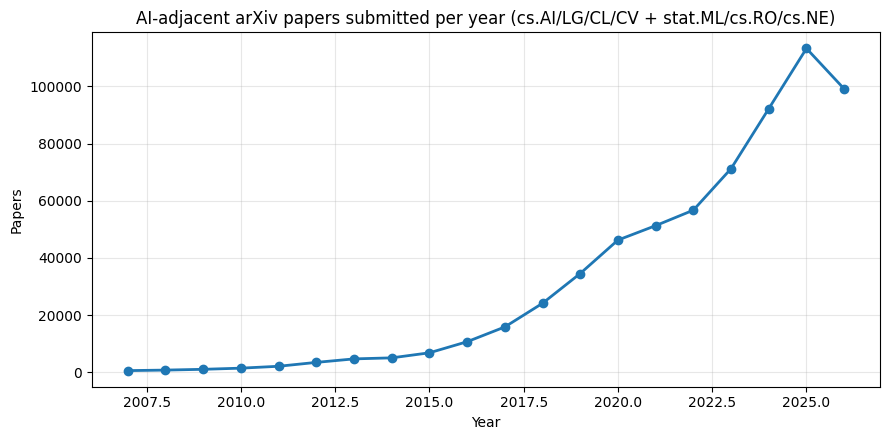

In [11]:
import matplotlib.pyplot as plt

papers["SubmittedDate"] = pd.to_datetime(papers["SubmittedDate"], errors="coerce")
by_year = papers["SubmittedDate"].dt.year.value_counts().sort_index()
by_year = by_year[by_year.index >= 2007]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(by_year.index, by_year.values, marker="o", linewidth=2)
ax.set_title("AI-adjacent arXiv papers submitted per year (cs.AI/LG/CL/CV + stat.ML/cs.RO/cs.NE)")
ax.set_xlabel("Year")
ax.set_ylabel("Papers")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
bridge_paper_category = pd.read_csv(os.path.join(OUT_DIR, "Bridge_Paper_Author.csv"))

C:\Users\thill\AppData\Local\Temp\ipykernel_42152\2092279665.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  bridge_paper_category = pd.read_csv(os.path.join(OUT_DIR, "Bridge_Paper_Author.csv"))


In [26]:
bridge_paper_category

,PaperID,AuthorName
0,704.0047,T. Kosel
1,704.0047,I. Grabec
2,704.005,T. Kosel
3,704.005,I. Grabec
4,704.0304,Carlos Gershenson
...,...,...
3018878,quant-ph/0609117,Carlo A. Trugenberger
3018879,quant-ph/0702072,Pierfrancesco La Mura
3018880,quant-ph/0702072,Lukasz Swiatczak
3018881,quant-ph/9802028,Alexander Yu. Vlasov
